# Image Classification with Machine Learning Pipeline
## EMNIST Letters Dataset — Midterm Project
**Kevin Indrawinata**

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from skimage.feature import hog
from mlxtend.data import loadlocal_mnist
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV, LeaveOneOut, cross_val_predict
from sklearn.metrics import (
    make_scorer, accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix
)
import pandas as pd
import random

/home/hekel/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


# 1. Load Dataset


In [2]:
# Update these paths to your dataset location
train_images, train_labels = loadlocal_mnist(
    images_path='mnist-dataset/letters/emnist-letters-train-images-idx3-ubyte',
    labels_path='mnist-dataset/letters/emnist-letters-train-labels-idx1-ubyte'
)

print(train_images.shape, train_labels.shape)

(124800, 784) (124800,)


# 2. Dataset Preparation

sampel 100 gambar per class

In [3]:
balanced_train_images = []
balanced_train_labels = []

np.random.seed(42)

# EMNIST Letters labels are 1-indexed (1=A ... 26=Z)
for i in range(1, 27):
    indices = np.where(train_labels == i)[0]
    selected_indices = np.random.choice(indices, size=100, replace=False)
    balanced_train_images.append(train_images[selected_indices])
    balanced_train_labels.append(train_labels[selected_indices])

balanced_train_images = np.vstack(balanced_train_images)
balanced_train_labels = np.hstack(balanced_train_labels)

print('Dataset shape:', balanced_train_images.shape, balanced_train_labels.shape)

Dataset shape: (2600, 784) (2600,)


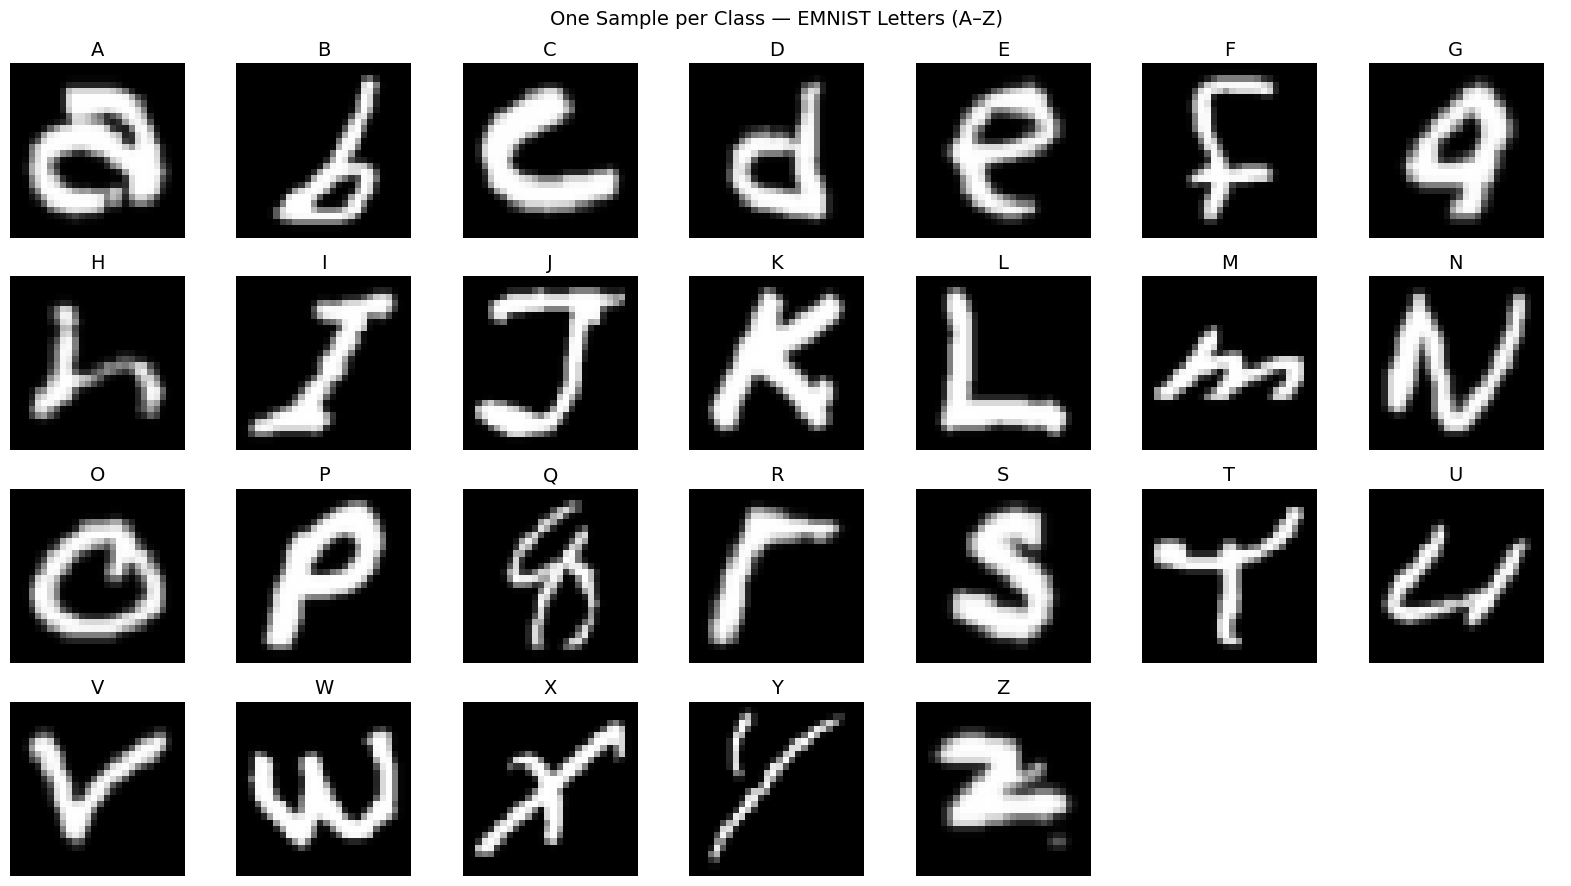

In [4]:
# Visualise one sample image
fig, axes = plt.subplots(4, 7, figsize=(16, 9))
axes = axes.flatten()
shown = {}

for img, label in zip(balanced_train_images, balanced_train_labels):
    if label not in shown:
        shown[label] = img

for i, label in enumerate(sorted(shown.keys())):
    axes[i].imshow(shown[label].reshape(28, 28).T, cmap='gray')
    axes[i].set_title(chr(int(label) + 64), fontsize=14)
    axes[i].axis('off')

# mengosongkan 2 box (karena huruf cuma ada 26)
for j in range(len(shown), len(axes)):
    axes[j].axis('off')

plt.suptitle('One Sample per Class — EMNIST Letters (A–Z)', fontsize=14)
plt.tight_layout()
plt.show()

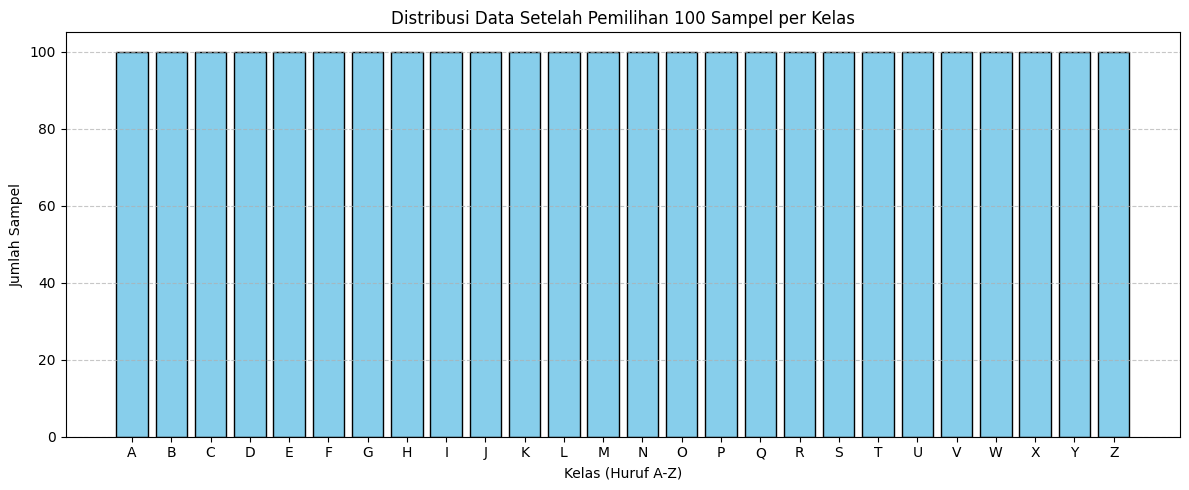

In [5]:
# Mengecek class, setiap kelas berisi 100 sampel
unique, counts = np.unique(balanced_train_labels, return_counts=True)
labels_as_letters = [chr(label + 64) for label in unique]

plt.figure(figsize=(12, 5))
plt.bar(labels_as_letters, counts, color='skyblue', edgecolor='black')
plt.title('Distribusi Data Setelah Pemilihan 100 Sampel per Kelas')
plt.xlabel('Kelas (Huruf A-Z)')
plt.ylabel('Jumlah Sampel')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [6]:
# Shuffle dataset
shuffle_idx = np.random.permutation(len(balanced_train_labels))
balanced_train_images = balanced_train_images[shuffle_idx]
balanced_train_labels = balanced_train_labels[shuffle_idx]

# 3. HOG Feature Extraction

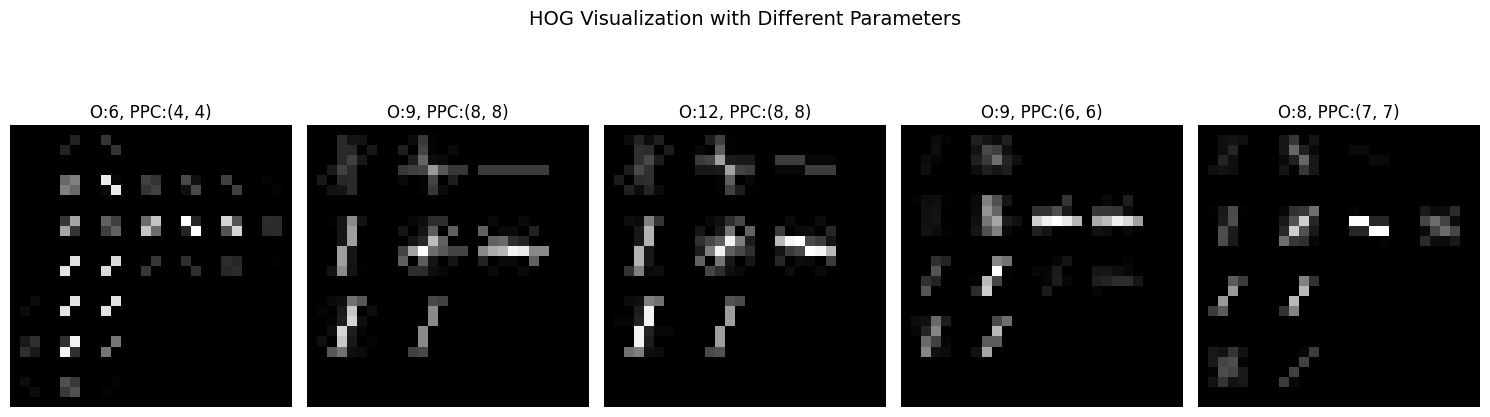

In [7]:
# visualisasi HOG
img = balanced_train_images[1].reshape(28, 28).T

param_sets = [
    {"orientations": 6,  "pixels_per_cell": (4, 4), "cells_per_block": (2, 2)},
    {"orientations": 9,  "pixels_per_cell": (8, 8), "cells_per_block": (2, 2)},
    {"orientations": 12, "pixels_per_cell": (8, 8), "cells_per_block": (3, 3)},
    {"orientations": 9,  "pixels_per_cell": (6, 6), "cells_per_block": (2, 2)},
    {"orientations": 8,  "pixels_per_cell": (7, 7), "cells_per_block": (2, 2)},
]

plt.figure(figsize=(15, 5))
for i, params in enumerate(param_sets):
    features, hog_image = hog(img, visualize=True, block_norm='L2', **params)
    plt.subplot(1, len(param_sets), i + 1)
    plt.imshow(hog_image, cmap='gray')
    plt.title(f"O:{params['orientations']}, PPC:{params['pixels_per_cell']}")
    plt.axis('off')

plt.suptitle('HOG Visualization with Different Parameters', fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
sample_feature, _ = hog(
    balanced_train_images[0].reshape(28, 28),
    orientations=6, pixels_per_cell=(8, 8), cells_per_block=(2, 2),
    visualize=True, block_norm='L2-Hys'
)
n_dims    = sample_feature.shape[0]
n_samples = balanced_train_images.shape[0]
print(f'Feature dimensions : {n_dims}')
print(f'Total samples      : {n_samples}')

X_all = np.zeros((n_samples, n_dims))
y_all = np.zeros(n_samples)

for i in range(n_samples):
    X_all[i], _ = hog(
        balanced_train_images[i].reshape(28, 28),
        orientations=6, pixels_per_cell=(8, 8), cells_per_block=(2, 2),
        visualize=True, block_norm='L2'
    )
    y_all[i] = balanced_train_labels[i]

print('HOG extraction complete. Feature matrix shape:', X_all.shape)

Feature dimensions : 96
Total samples      : 2600
HOG extraction complete. Feature matrix shape: (2600, 96)


# 4. Train / Test Split (80% / 20%)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, shuffle=False
)

print('X_train:', X_train.shape, '| y_train:', y_train.shape)
print('X_test :', X_test.shape,  '| y_test :', y_test.shape)

X_train: (2080, 96) | y_train: (2080,)
X_test : (520, 96) | y_test : (520,)


# 5. SVM with Grid Search

Use GridSearchCV to find the best combination of SVM hyperparameters (C, kernel, gamma).
The best model is selected based on the highest F1-score across 5-fold cross-validation.

In [10]:
clf = SVC()

scoring = {
    'accuracy' : make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='macro'),
    'recall'   : make_scorer(recall_score,    average='macro'),
    'f1'       : make_scorer(f1_score,        average='macro'),
}

param_grid = {
    'C'     : [0.1, 1, 3.2, 5.0, 2.4, 10.0],
    'kernel': ['rbf', 'linear'],
    'gamma' : ['scale', 'auto'],
}

grid_search = GridSearchCV(
    clf, param_grid,
    scoring  = scoring,
    cv       = 5,
    refit    = 'f1',     
    verbose  = 1,
    n_jobs   = -1,
)
grid_search.fit(X_train, y_train)

cv_results  = pd.DataFrame(grid_search.cv_results_)
cv_metrics  = cv_results[[
    'params', 'mean_test_accuracy', 'mean_test_precision',
    'mean_test_recall', 'mean_test_f1'
]]
print('\n=== Hasil Evaluasi Training (Cross-Validation) ===')
print(cv_metrics.sort_values(by='mean_test_f1', ascending=False).to_string(index=False))

Fitting 5 folds for each of 24 candidates, totalling 120 fits


/home/hekel/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hekel/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hekel/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hekel/.


=== Hasil Evaluasi Training (Cross-Validation) ===
                                           params  mean_test_accuracy  mean_test_precision  mean_test_recall  mean_test_f1
   {'C': 10.0, 'gamma': 'scale', 'kernel': 'rbf'}            0.779808             0.788431          0.780033      0.778673
    {'C': 2.4, 'gamma': 'scale', 'kernel': 'rbf'}            0.775962             0.788926          0.775849      0.775841
    {'C': 5.0, 'gamma': 'scale', 'kernel': 'rbf'}            0.775000             0.785454          0.774940      0.774005
    {'C': 3.2, 'gamma': 'scale', 'kernel': 'rbf'}            0.773558             0.784434          0.773316      0.772797
      {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}            0.760577             0.776159          0.760433      0.761162
  {'C': 3.2, 'gamma': 'auto', 'kernel': 'linear'}            0.758654             0.768105          0.758286      0.757573
 {'C': 3.2, 'gamma': 'scale', 'kernel': 'linear'}            0.758654             0.768

In [11]:
best_model = grid_search.best_estimator_
print('\n=== Parameter Terbaik ===')
print(grid_search.best_params_)


=== Parameter Terbaik ===
{'C': 10.0, 'gamma': 'scale', 'kernel': 'rbf'}


# 6. Evaluation — Leave-One-Out Cross-Validation (LOOCV)


In [12]:
loo = LeaveOneOut()
y_pred_loocv = cross_val_predict(best_model, X_train, y_train, cv=loo)

print('LOOCV Accuracy : {:.2f}%'.format(accuracy_score(y_train, y_pred_loocv) * 100))
print('Precision      : {:.2f}%'.format(precision_score(y_train, y_pred_loocv, average='weighted') * 100))
print('Recall         : {:.2f}%'.format(recall_score(y_train,    y_pred_loocv, average='weighted') * 100))
print('F1 Score       : {:.2f}%'.format(f1_score(y_train,        y_pred_loocv, average='weighted') * 100))

cof_LOOCV = confusion_matrix(y_train, y_pred_loocv)

LOOCV Accuracy : 79.38%
Precision      : 79.58%
Recall         : 79.38%
F1 Score       : 79.35%


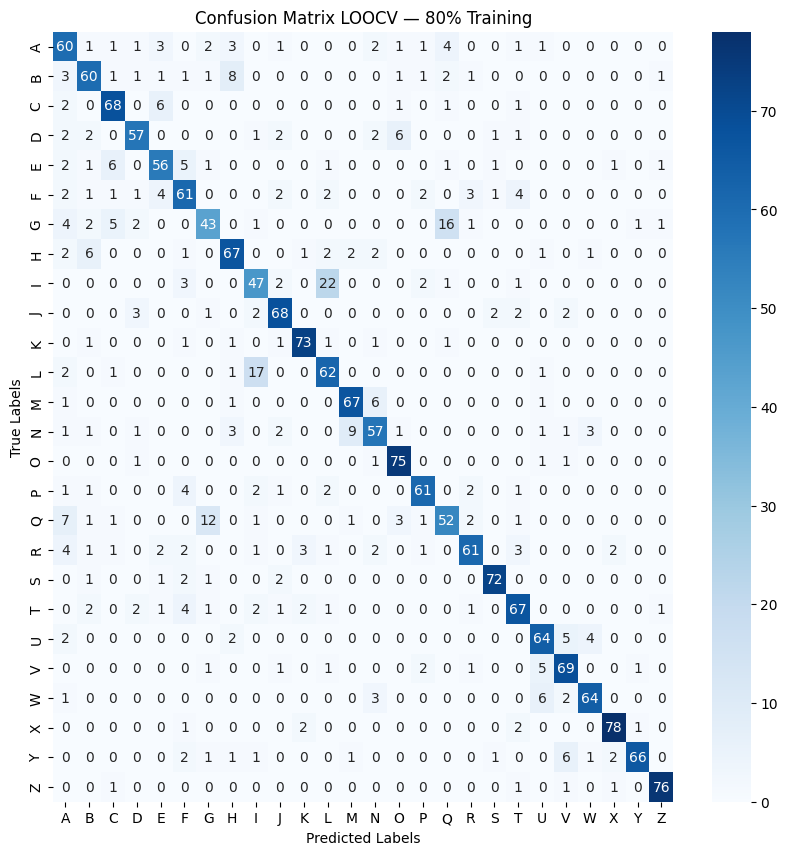

In [20]:
letter_labels = [chr(int(l) + 64) for l in np.unique(y_train)]

plt.figure(figsize=(10, 10))
sns.heatmap(
    cof_LOOCV, annot=True, fmt='d', cmap='Blues',
    xticklabels=letter_labels,
    yticklabels=letter_labels
)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix LOOCV — 80% Training')
plt.show()

# 7. Evaluation — 20% Test Set

In [14]:
pred_test = best_model.predict(X_test)

print('Test Accuracy  : {:.2f}%'.format(accuracy_score(y_test, pred_test) * 100))
print('Test Precision : {:.2f}'.format(precision_score(y_test, pred_test, average='macro')))
print('Test Recall    : {:.2f}'.format(recall_score(y_test,    pred_test, average='weighted')))
print('Test F1 Score  : {:.2f}'.format(f1_score(y_test,        pred_test, average='weighted')))

conf_mat = confusion_matrix(y_test, pred_test)

Test Accuracy  : 78.27%
Test Precision : 0.79
Test Recall    : 0.78
Test F1 Score  : 0.78


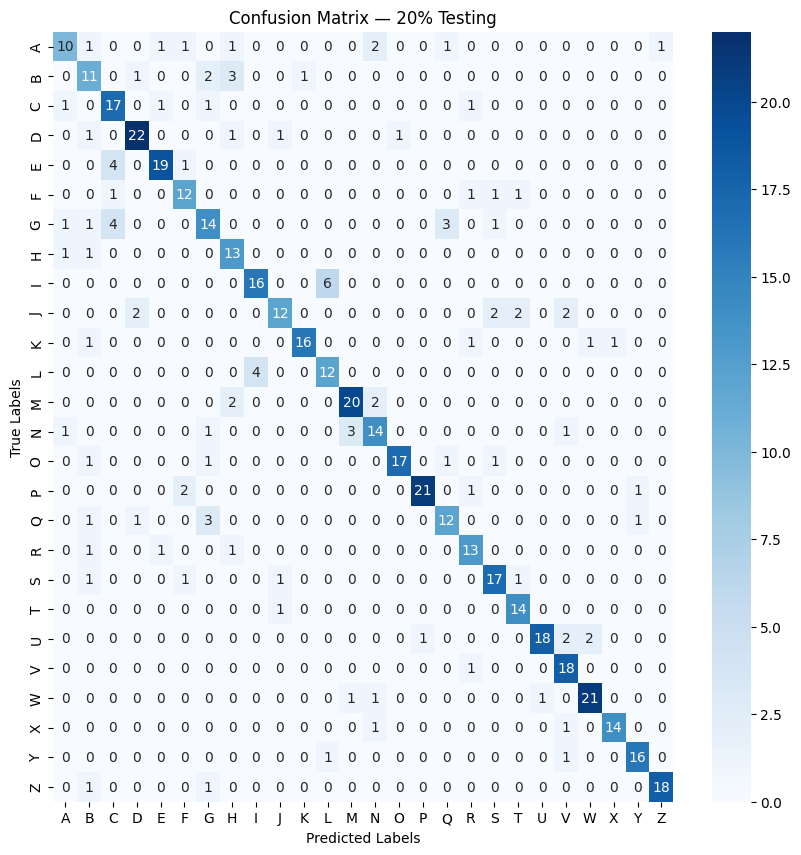

In [15]:
letter_labels = [chr(int(l) + 64) for l in np.unique(y_train)]

plt.figure(figsize=(10, 10))
sns.heatmap(
    conf_mat, annot=True, fmt='d', cmap='Blues',
    xticklabels=letter_labels,
    yticklabels=letter_labels
)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix — 20% Testing')
plt.show()

# 8. Testing Model

Melakukan tes dari beberapa dataset

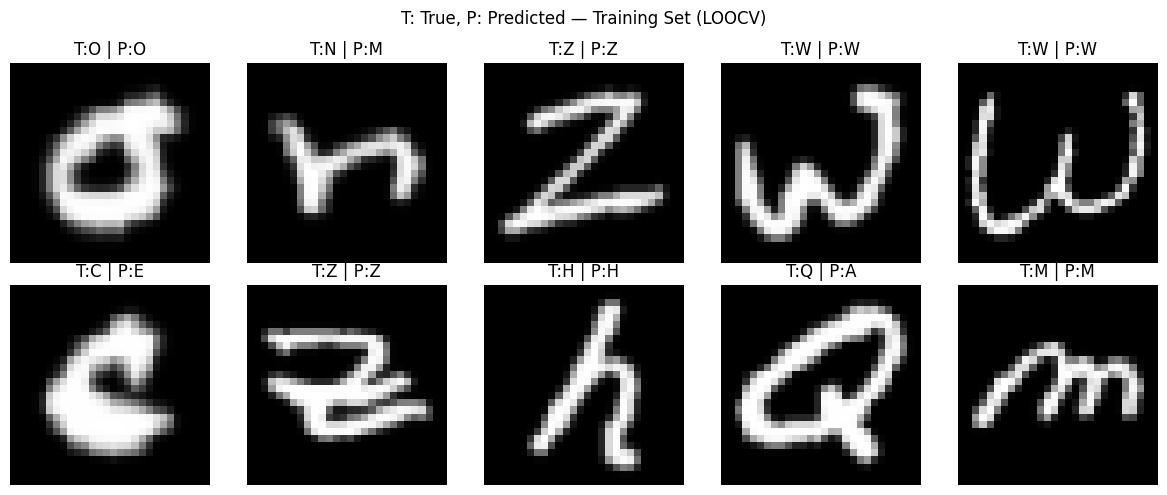

In [ ]:
# 10 tes dari training set
indices = random.sample(range(len(X_train)), 10)
plt.figure(figsize=(12, 5))
for i, idx in enumerate(indices):
    img        = balanced_train_images[idx].reshape(28, 28).T
    true_label = y_train[idx]
    pred_label = y_pred_loocv[idx]
    plt.subplot(2, 5, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"T:{chr(int(true_label) + 64)} | P:{chr(int(pred_label) + 64)}")
    plt.axis('off')
plt.suptitle('T: True, P: Predicted — Training Set (LOOCV)')
plt.tight_layout()
plt.show()

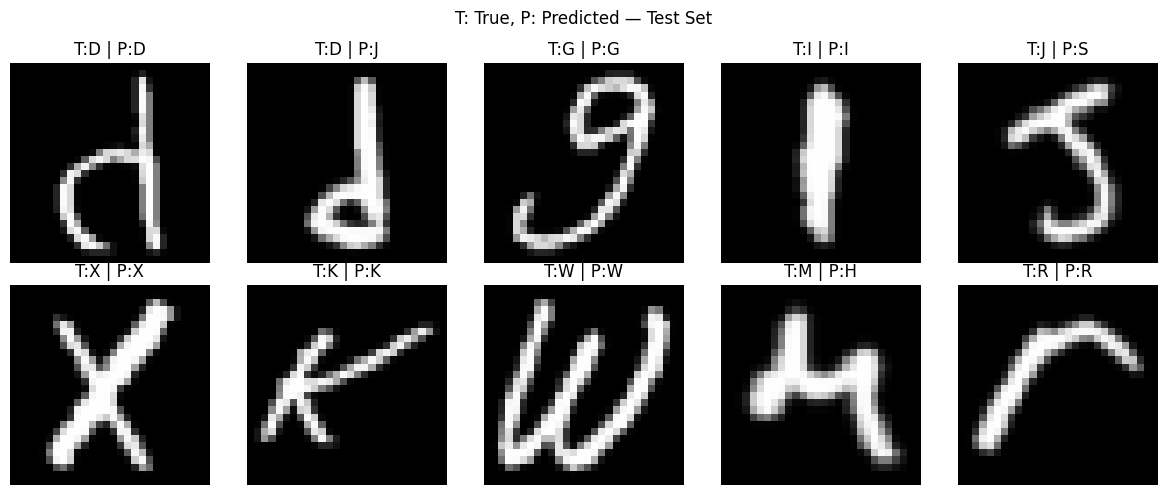

In [ ]:
# 10 tes dari test set
indices = random.sample(range(len(X_test)), 10)
plt.figure(figsize=(12, 5))
for i, idx in enumerate(indices):
    img        = balanced_train_images[idx + 2080].reshape(28, 28).T
    true_label = y_test[idx]
    pred_label = pred_test[idx]
    plt.subplot(2, 5, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"T:{chr(int(true_label) + 64)} | P:{chr(int(pred_label) + 64)}")
    plt.axis('off')
plt.suptitle('T: True, P: Predicted — Test Set')
plt.tight_layout()
plt.show()